# Hands-On with Real Data: Autoencoders and Generative Adversarial Network (Vanila Encoder Version)


## Objectives
- Implement and train Vanilla Autoencoder, Variational Autoencoder (VAE), and Generative Adversarial Network
(GAN) models.
- Preprocess and explore MNIST, Fashion-MNIST, and a combined dataset (MNIST + Fashion-MNIST).
- Generate synthetic images using each trained model.
- Compare the quality and characteristics of generated images across datasets and models.
- Analyze the impact of training on single vs. combined datasets.
- Use visualization techniques to interpret results

## Dataset Description 
We will work with two commonly used image datasets:
- **Fashion-MNIST:** Fashion item images (10 classes), 28×28 pixels, 60,000 training and 10,000 test. 
- **MNIST:** Handwritten digits (0–9), 28×28 pixels, 60,000 training and 10,000 test images 
- **Combined dataset:** You will also create a combined dataset by concatenating the MNIST and Fashion-MNIST 
sets. 

# Implementation

***Imports***

In [27]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from keras import ops
import numpy as np
import keras

## Step 1: Data Loading and Preprocessing

#### **download the datasets using keras**

In [28]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

(x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = tf.keras.datasets.fashion_mnist.load_data()

In [29]:
y_train_mnist.shape

(60000,)

In [30]:
print(np.unique(y_train_fmnist))
y_train_fmnist = np.array(y_train_fmnist)
y_train_fmnist += 10
print(np.unique(y_train_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


In [31]:
print(np.unique(y_test_fmnist))
y_test_fmnist = np.array(y_test_fmnist)
y_test_fmnist += 10
print(np.unique(y_test_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


#### **Normalize Data**

In [32]:
x_train_mnist_normalized = x_train_mnist / 255.0
x_test_mnist_normalized = x_test_mnist / 255.0

x_train_fmnist_normalized = x_train_fmnist / 255.0
x_test_fmnist_normalized = x_test_fmnist / 255.0

#### **Create a combined dataset by concatenating the MNIST and Fashion-MNIST training sets**

In [33]:
x_train_combined = np.concatenate([x_train_mnist_normalized, x_train_fmnist_normalized], axis=0)
y_train_combined = np.concatenate([y_train_mnist, y_train_fmnist], axis=0)

x_test_combined = np.concatenate([x_test_mnist_normalized, x_test_fmnist_normalized], axis=0)
y_test_combined = np.concatenate([y_test_mnist, y_test_fmnist], axis=0)

#### **Explore the datasets using visualization techniques (e.g., sample images, class distributions)**

In [34]:
uniques_mnist = np.unique(y_train_mnist)
list_lables_mnist = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
dict_labels_mnist = {i: list_lables_mnist[i] for i in range(len(list_lables_mnist))}
dict_labels_mnist

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9'}

In [35]:
uniques_fminst = np.unique(y_train_fmnist)
list_lables_fminst = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
dict_labels_fminst = {i+10: list_lables_fminst[i] for i in range(len(list_lables_fminst))}
dict_labels_fminst

{10: 'T-shirt/top',
 11: 'Trouser',
 12: 'Pullover',
 13: 'Dress',
 14: 'Coat',
 15: 'Sandal',
 16: 'Shirt',
 17: 'Sneaker',
 18: 'Bag',
 19: 'Ankle boot'}

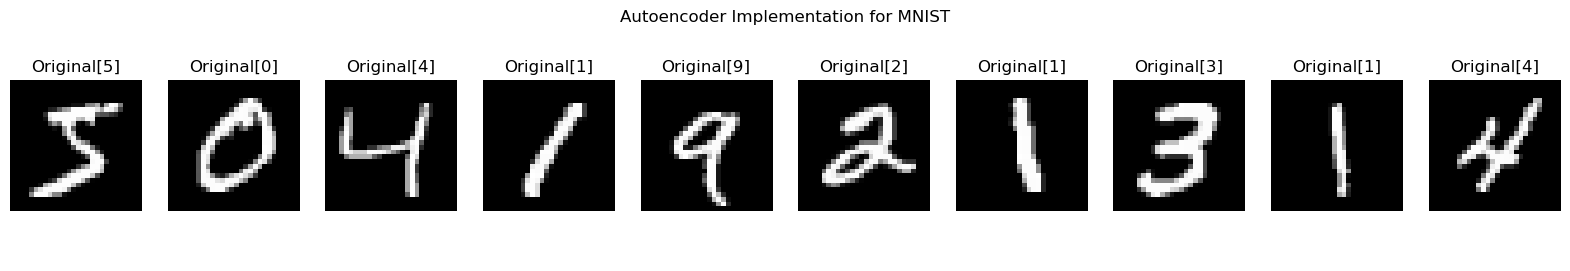

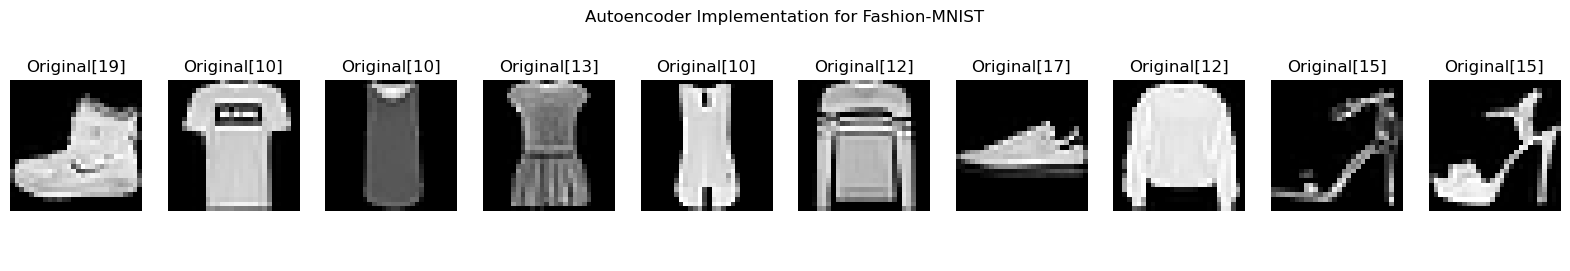

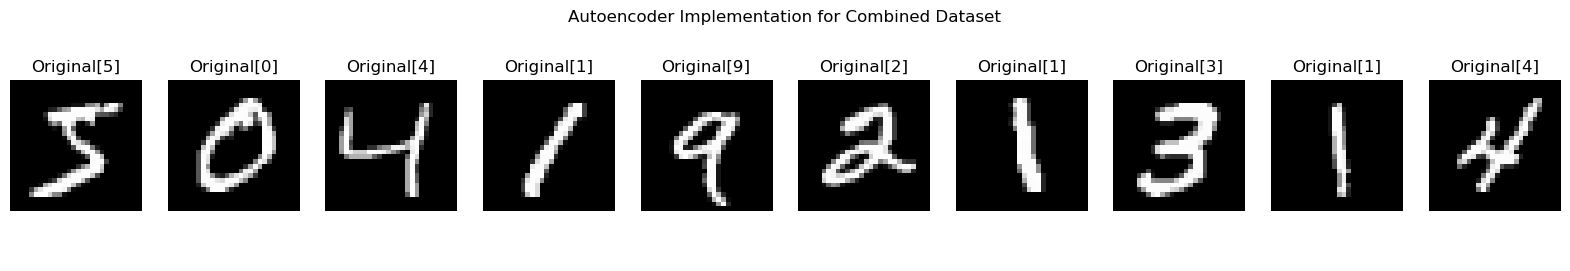

In [36]:
def plot_images_single_dataset(original_images, class_lables, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 3))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{class_lables[i]}]")
        plt.axis('off')

plot_images_single_dataset(x_train_mnist, y_train_mnist, 10, "MNIST")
plot_images_single_dataset(x_train_fmnist, y_train_fmnist, 10, "Fashion-MNIST")
plot_images_single_dataset(x_train_combined, y_train_combined, 10, "Combined Dataset")

Histogram of Class for combined dataset

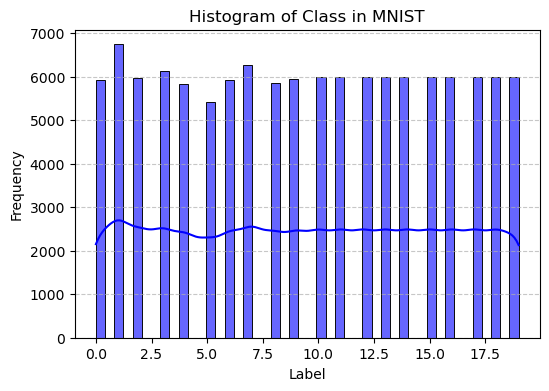

In [37]:
def plot_histogram(column_data, default_bin=10, dataset="MNIST"):
    iqr = np.percentile(column_data, 75) - np.percentile(column_data, 25)
    bin_width_fd = 2 * iqr / (len(column_data) ** (1 / 3))
    if bin_width_fd > 0:
        n_bins_fd = int(np.ceil((column_data.max() - column_data.min()) / bin_width_fd))
    else:
        n_bins_fd = default_bin

    plt.figure(figsize=(6, 4))
    sns.histplot(column_data, bins=n_bins_fd, kde=True, color="blue", alpha=0.6)
    plt.title(f'Histogram of Class in {dataset}')
    plt.xlabel('Label')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_histogram(y_train_combined)

#### **Comment on differences between the datasets and potential challenges when combining them.**

---

One of the main potential issues we noticed was that both MNIST and Fashion-MNIST use integer labels from 0-9, but they represent different things: digits and clothing). If we simply concatenate them, class 0 will be automatically assigned to both 0 and the t-shirt. To prevent this from happening, we can re mapping the labels so that the combined dataset has classes from 0 to 19 (20 classes for both datasets). The other difference is that MNIST digits are simple strokes while Fashion-MNIST items have more complex textures and shapes. 

---

## Step 3: Train Variational Autoencoder (VAE) Models

#### **Split Dataset**

In [38]:
x_train_mnist_normalized.shape

(60000, 28, 28)

In [39]:
y_train_mnist.shape

(60000,)

In [40]:
x_train_mnist, x_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    x_train_mnist_normalized, y_train_mnist, test_size=0.3, random_state=42
)

x_train_fmnist, x_val_fmnist, y_train_fmnist, y_val_fmnist = train_test_split(
    x_train_fmnist_normalized, y_train_fmnist, test_size=0.3, random_state=42
)

x_train_combined, x_val_combined, y_train_combined, y_val_combined = train_test_split(
    x_train_combined, y_train_combined, test_size=0.3, random_state=42
)

#### **Reshape the dataset**

In [41]:
x_train_mnist_processed = np.expand_dims(x_train_mnist, -1)
x_train_fmnist_processed = np.expand_dims(x_train_fmnist, -1)
x_train_combined_processed = np.expand_dims(x_train_combined, -1)

x_val_mnist_processed = np.expand_dims(x_val_mnist, -1)
x_val_fmnist_processed = np.expand_dims(x_val_fmnist, -1)
x_val_combined_processed = np.expand_dims(x_val_combined, -1)

#### **VAE (Variational Autoencoder)**

In [42]:
class Sampling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

In [43]:
def build_vae_models(latent_dim=2):
    encoder_inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")
    x = layers.Flatten()(encoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")
    x = layers.Dense(128, activation='relu')(latent_inputs)
    x = layers.Dense(28 * 28 * 1, activation='sigmoid')(x)
    decoder_outputs = layers.Reshape((28, 28, 1), name="decoder_output")(x)
    decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

    return encoder, decoder

In [44]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = ops.mean(
                ops.sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

#### **Visualize the latent space representation of the test data using scatter plots colored by class**

In [45]:
def plot_label_clusters(vae, data, labels):
    z_mean, _, _ = vae.encoder.predict(data, verbose=0)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()

#### **Generate a grid of synthetic images after training completion for each dataset.**

In [46]:
def plot_latent_space(vae, n=30, figsize=15):
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n))
    
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

##### VAE (MNIST Version)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 784)       │          0 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    100,480 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_3          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,996 (394.52 KB)

 Trainable params: 100,996 (394.52 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Reshape)        │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,520 (396.56 KB)

 Trainable params: 101,520 (396.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 19.0578 - loss: 287.6062 - reconstruction_loss: 268.5485
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.4253 - loss: 184.4058 - reconstruction_loss: 178.9805
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.7498 - loss: 174.7938 - reconstruction_loss: 170.0440
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.7264 - loss: 170.3618 - reconstruction_loss: 165.6354
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.8049 - loss: 168.2670 - reconstruction_loss: 163.4621
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 4.8933 - loss: 166.4939 - reconstruction_loss: 161.6005
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.9267 - loss: 165.1861 - reconstruction_loss: 160.2594
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.9531 - loss: 164.5990 - reconstruction_loss: 159.6459
Epoch 9/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/

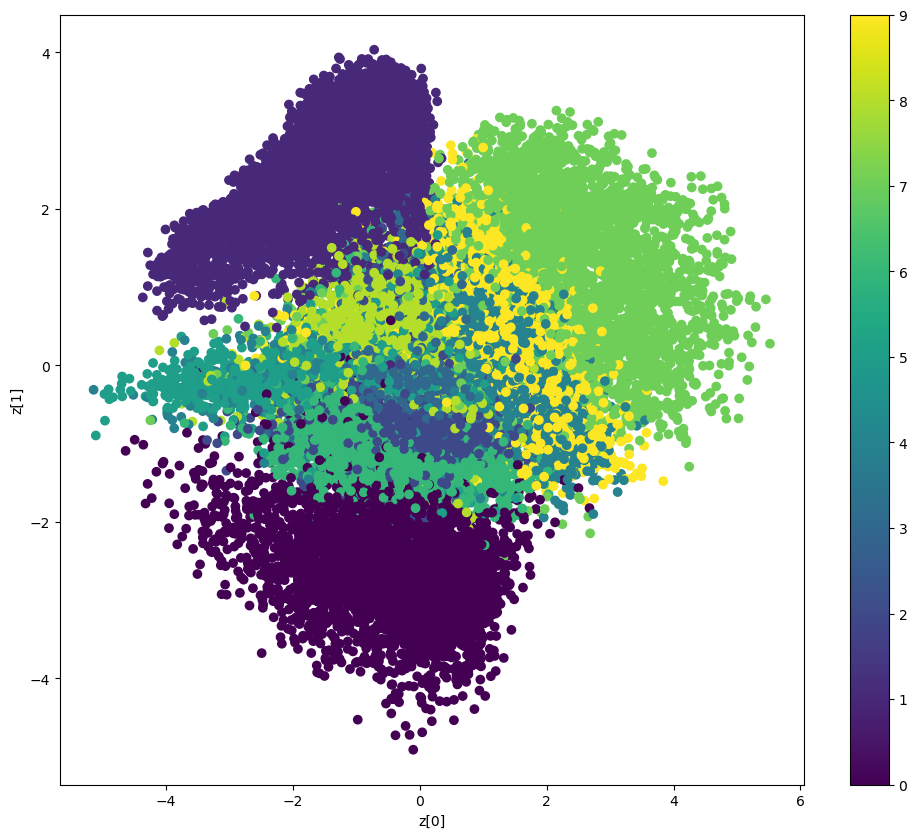

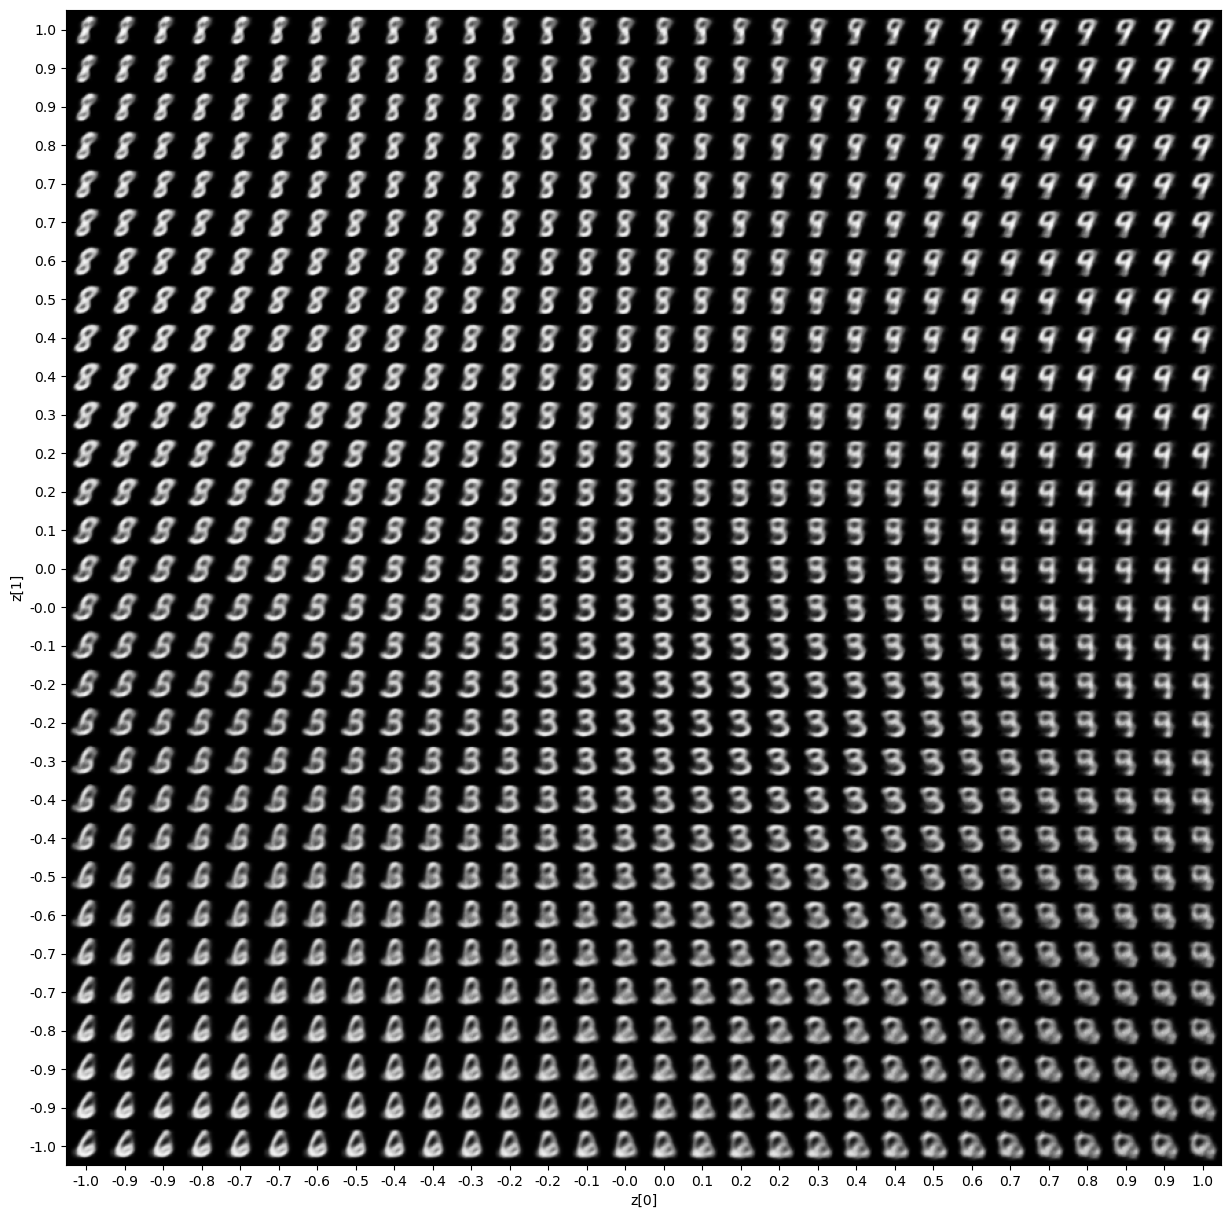

In [47]:
encoder_MNIST, decoder_MNIST = build_vae_models(latent_dim=2)
encoder_MNIST.summary()
decoder_MNIST.summary()

vae_MNIST = VAE(encoder_MNIST, decoder_MNIST)
vae_MNIST.compile(optimizer=keras.optimizers.Adam())
vae_MNIST.fit(x_train_mnist_processed, epochs=30, batch_size=128)

plot_label_clusters(vae_MNIST, x_train_mnist_processed, y_train_mnist)

plot_latent_space(vae_MNIST)

In [48]:
reconstructed_images = vae_MNIST.predict(x_val_mnist_processed)

NotImplementedError: Exception encountered when calling VAE.call().

[1mModel VAE does not have a `call()` method implemented.[0m

Arguments received by VAE.call():
  • args=('tf.Tensor(shape=(32, 28, 28, 1), dtype=float32)',)
  • kwargs=<class 'inspect._empty'>

##### VAE (Fashion - MNIST Version)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - kl_loss: 2.9099 - loss: 413.6859 - reconstruction_loss: 410.7760
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - kl_loss: 5.7114 - loss: 334.3071 - reconstruction_loss: 328.5958
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - kl_loss: 5.8922 - loss: 319.3810 - reconstruction_loss: 313.4888
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - kl_loss: 5.6080 - loss: 313.7055 - reconstruction_loss: 308.0975
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - kl_loss: 5.3412 - loss: 308.5627 - reconstruction_loss: 303.2215
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - kl_loss: 5.1847 - loss: 307.7654 - reconstruction_loss: 302.5806
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - kl_loss: 5.1577 - loss: 305.3625 - reconstruction_loss: 300.2048
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - kl_loss: 5.0771 - loss: 303.4964 - reconstruction_loss: 298.4193
Epoch 9/30
329/329 ━━━━━━━━━━━━━

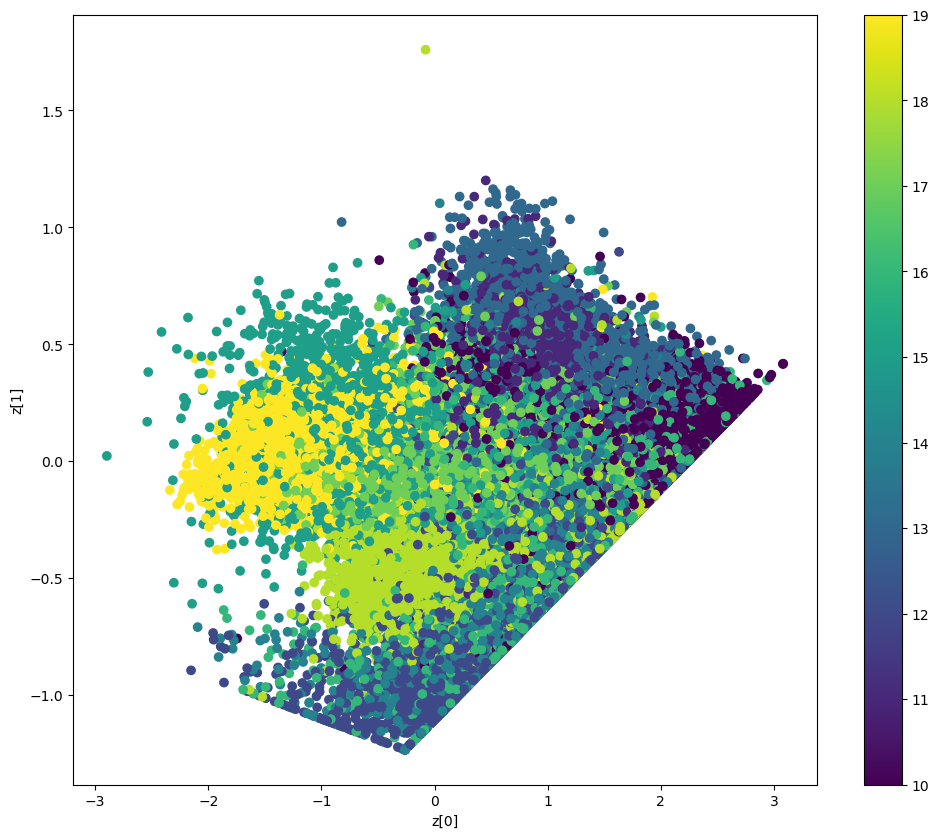

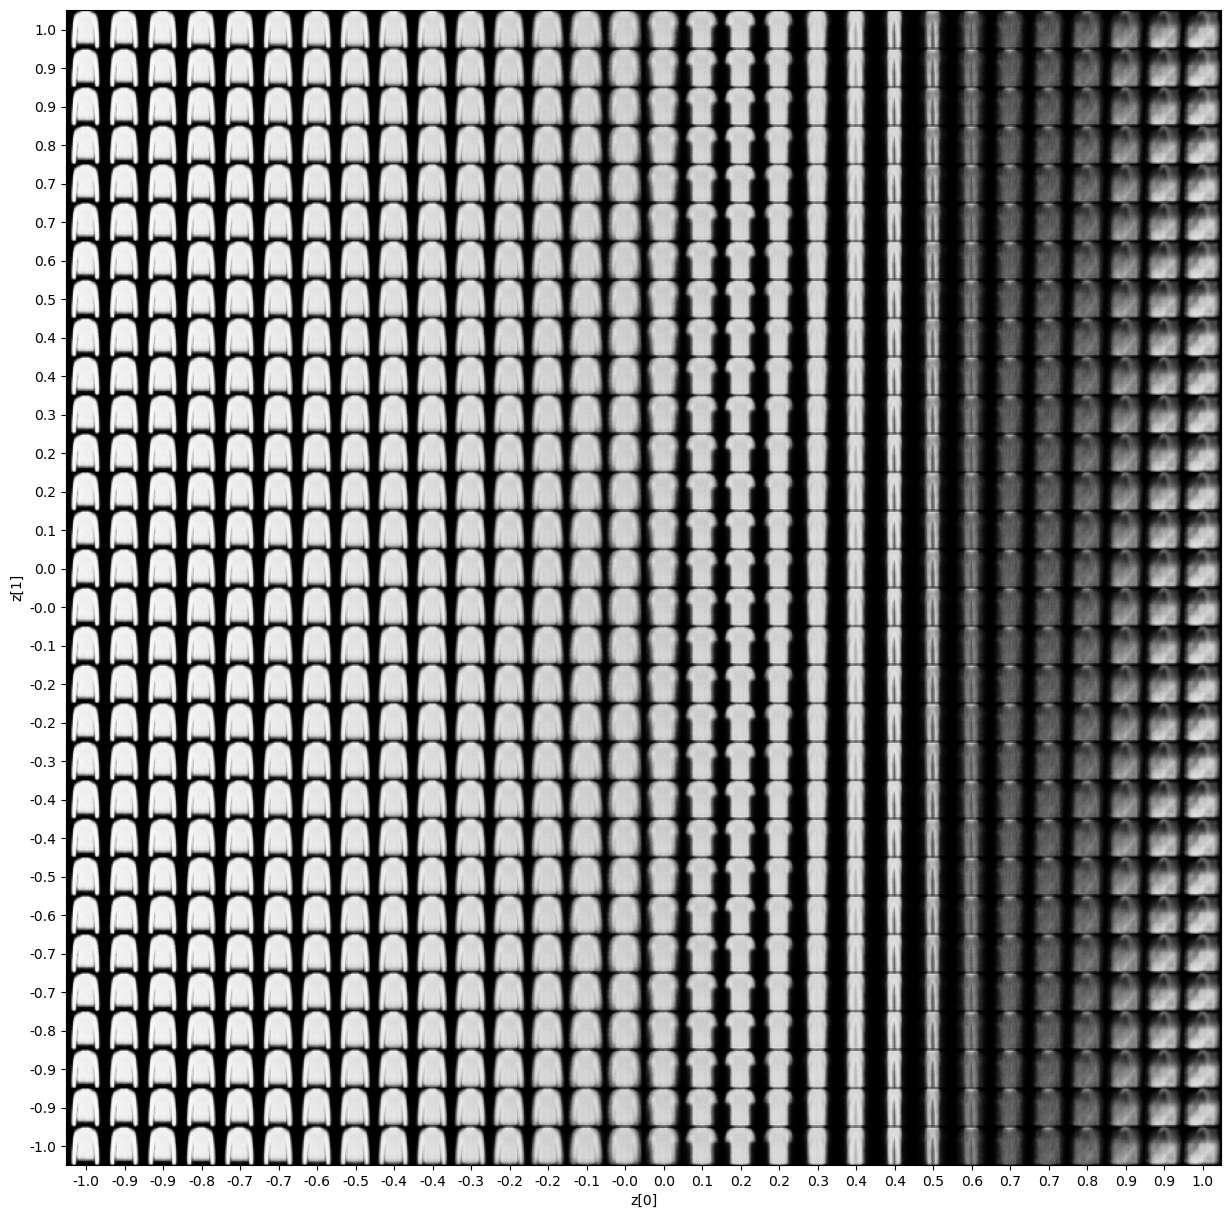

In [23]:
encoder_FMNIST, decoder_FMNIST = build_vae_models(latent_dim=2)
encoder_FMNIST.summary()
decoder_FMNIST.summary()

vae_FMNIST = VAE(encoder_FMNIST, decoder_FMNIST)
vae_FMNIST.compile(optimizer=keras.optimizers.Adam())
vae_FMNIST.fit(x_train_fmnist_processed, epochs=30, batch_size=128)

plot_label_clusters(vae_MNIST, x_train_fmnist_processed, y_train_fmnist)

plot_latent_space(vae_FMNIST)

##### VAE (Combined Version)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │     50,192 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - kl_loss: 5.0807 - loss: 399.4427 - reconstruction_loss: 394.3620
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - kl_loss: 9.2238 - loss: 294.8946 - reconstruction_loss: 285.6708
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - kl_loss: 8.0917 - loss: 282.3067 - reconstruction_loss: 274.2150
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - kl_loss: 7.6568 - loss: 277.7955 - reconstruction_loss: 270.1387
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - kl_loss: 7.4842 - loss: 275.5188 - reconstruction_loss: 268.0346
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - kl_loss: 7.3319 - loss: 273.7974 - reconstruction_loss: 266.4655
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - kl_loss: 7.3202 - loss: 271.3183 - reconstruction_loss: 263.9981
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - kl_loss: 7.2682 - loss: 271.8710 - reconstruction_loss: 264.6028
Epoch 9/30
329/329 ━━━━━━━━━━━━━

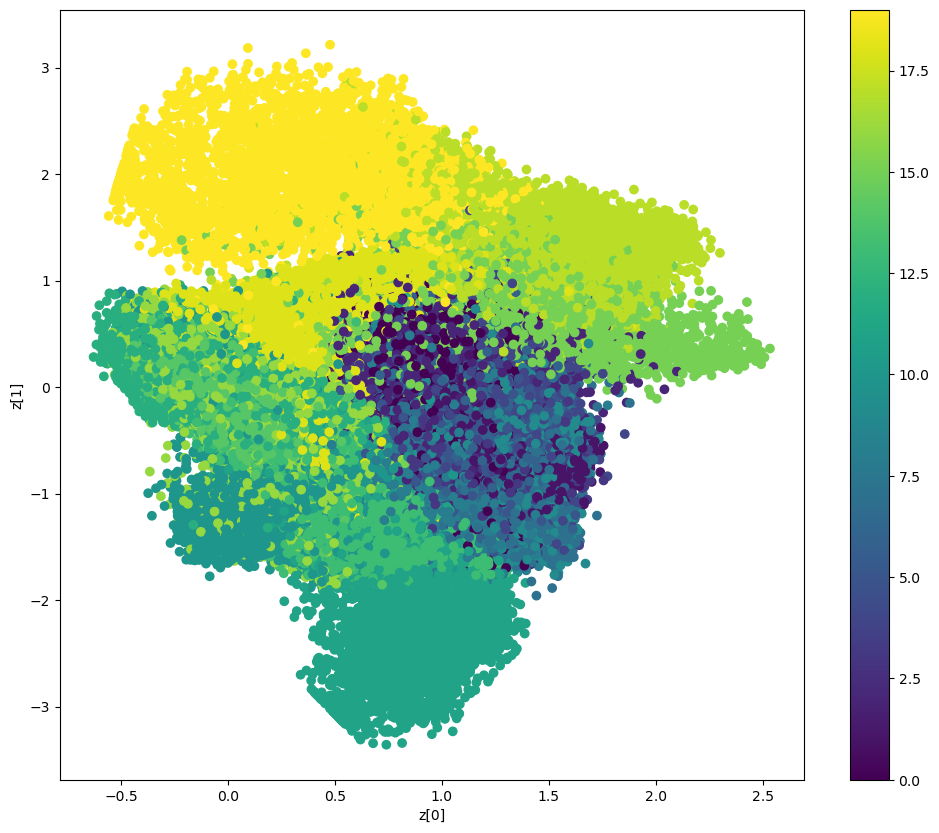

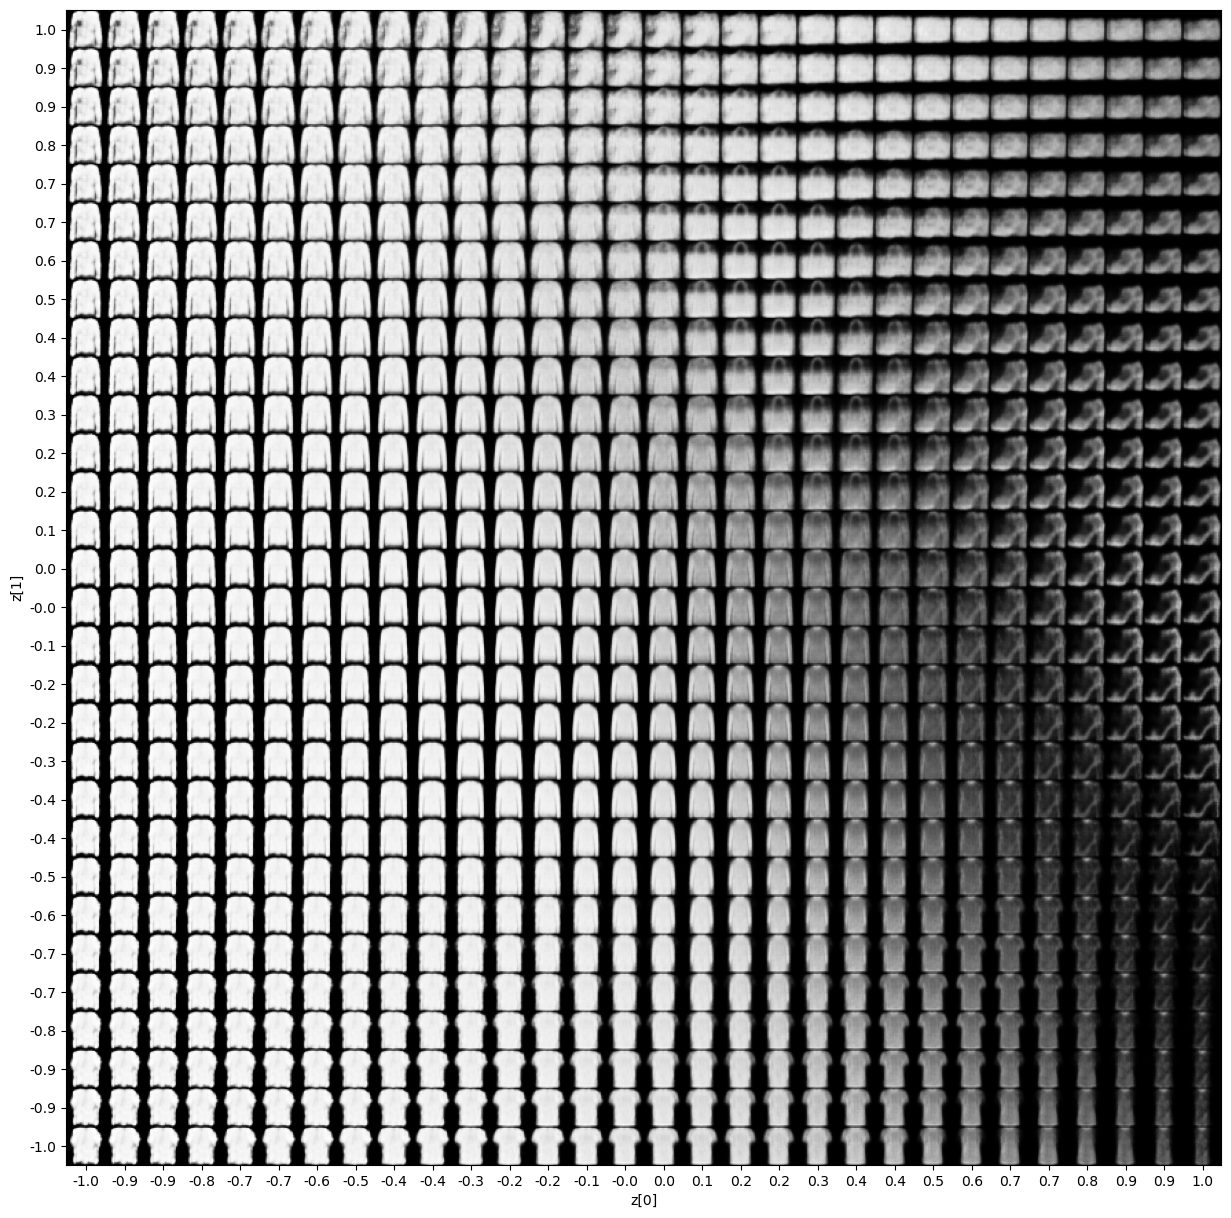

In [24]:
encoder_Combined, decoder_Combined = build_vae_models(latent_dim=2)
encoder_Combined.summary()
decoder_Combined.summary()

vae_Combined = VAE(encoder_Combined, decoder_Combined)
vae_Combined.compile(optimizer=keras.optimizers.Adam())
vae_Combined.fit(x_train_fmnist_processed, epochs=30, batch_size=128)

plot_label_clusters(vae_Combined, x_train_combined_processed, y_train_combined)

plot_latent_space(vae_Combined)